In [ ]:
# path = "/root/.cache/kagglehub/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed/versions/1"

In [3]:
import numpy as np
import random
import tensorflow as tf
import requests, pickle

def set_seed(seed_value=42):
    random.seed(seed_value)
    np.random.seed(seed_value)
    tf.random.set_seed(seed_value)
    os.environ['PYTHONHASHSEED'] = str(seed_value)

### Data Preprocessing

* แบ่ง dataset สำหรับการเทรนและทดสอบ โดยจะแบ่งเป็น system test (สำหรับทดสอบทั้ง pipeline):train and evaluate = 20:80 และแบ่ง train and evaluate เป็น train:val:test = 70:15:15
* Resize ภาพ เป็นขนาด 1024x1024 โดยวิธี letterbox resize ซึ่งจะปรับขนาดให้อัตราส่วนภาพเดิมยังคงอยู่ แต่ถูกแสดงผลภายในเฟรมที่มีอัตราส่วนที่กำหนด โดยการเพิ่มแถบสีดำไว้ที่ด้านบน-ล่าง หรือซ้าย-ขวา เพื่อป้องกันภาพบิดเบี้ยวหรือถูกตัด
* เปลี่ยน annotaion แบบ polygon ไปเป็น bounding box เนื่องจากต้องการทำ data augmentation (flip ภาพจะทำการปรับ annotaion ได้ง่ายกว่า) เพื่อเพิ่มจำนวน data เพราะ dataset มีจำนวนน้อย

In [4]:
import os
import glob
import random
import shutil
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from collections import defaultdict

# ==============================
# CONFIG
# ==============================

DATASET_ROOT = path
OUTPUT_ROOT = "detector_dataset"

IMG_SIZE = 1024
SEED = 42

set_seed(42)

# ==============================
# GET IMAGE PATHS PER CLASS
# ==============================

class_images = defaultdict(list)

for cls in os.listdir(DATASET_ROOT):

    class_dir = os.path.join(DATASET_ROOT, cls, cls)

    if not os.path.isdir(class_dir):
        continue

    for img in glob.glob(os.path.join(class_dir, "*.bmp")):
        class_images[cls].append(img)

# ==============================
# STRATIFIED SPLIT
# ==============================

splits = {
    "train": [],
    "val": [],
    "test": [],
    "system_test": []
}

for cls, images in class_images.items():

    # system test 20%
    train_eval, system_test = train_test_split(
        images,
        test_size=0.20,
        random_state=SEED
    )

    # remaining 80%
    train, temp = train_test_split(
        train_eval,
        test_size=0.30,
        random_state=SEED
    )

    val, test = train_test_split(
        temp,
        test_size=0.50,
        random_state=SEED
    )

    splits["train"].extend(train)
    splits["val"].extend(val)
    splits["test"].extend(test)
    splits["system_test"].extend(system_test)

# ==============================
# PRINT CLASS COUNT
# ==============================

print("\n================ Dataset Distribution ================\n")

for split in splits:

    counter = defaultdict(int)

    for img in splits[split]:

        cls = os.path.basename(os.path.dirname(os.path.dirname(img)))
        counter[cls] += 1

    print(f"\n{split.upper()}")

    total = 0

    for c in sorted(counter.keys()):

        # print(f"{c:25s} : {counter[c]}")
        total += counter[c]

    # print("----------------------------------")
    print(f"TOTAL IMAGES : {total}")

# ==============================
# CREATE OUTPUT FOLDERS
# ==============================

for split in splits:

    os.makedirs(f"{OUTPUT_ROOT}/{split}/images", exist_ok=True)
    os.makedirs(f"{OUTPUT_ROOT}/{split}/labels", exist_ok=True)

# ==============================
# READ DAT POLYGON
# ==============================

def read_polygon(dat_path):

    pts = []

    with open(dat_path) as f:
        for line in f:

            line = line.strip()

            if not line:
                continue

            x, y = line.split(",")

            pts.append([float(x), float(y)])

    return np.array(pts)


# ==============================
# POLYGON -> BBOX
# ==============================

def polygon_to_bbox(poly):

    xmin = np.min(poly[:,0])
    ymin = np.min(poly[:,1])
    xmax = np.max(poly[:,0])
    ymax = np.max(poly[:,1])

    return xmin, ymin, xmax, ymax


# ==============================
# LETTERBOX RESIZE
# ==============================

def letterbox(image):

    h, w = image.shape[:2]

    scale = min(IMG_SIZE/w, IMG_SIZE/h)

    nw = int(w*scale)
    nh = int(h*scale)

    resized = cv2.resize(image,(nw,nh))

    canvas = np.zeros((IMG_SIZE,IMG_SIZE,3),dtype=np.uint8)

    pad_x = (IMG_SIZE-nw)//2
    pad_y = (IMG_SIZE-nh)//2

    canvas[pad_y:pad_y+nh,pad_x:pad_x+nw] = resized

    return canvas, scale, pad_x, pad_y


# ==============================
# PROCESS IMAGE
# ==============================

for split in splits:

    for img_path in splits[split]:

        img = cv2.imread(img_path)

        letter_img, scale, px, py = letterbox(img)

        base = os.path.splitext(os.path.basename(img_path))[0]
        folder = os.path.dirname(img_path)

        cyt_files = glob.glob(os.path.join(folder,f"{base}_cyt*.dat"))

        boxes = []

        for dat in cyt_files:

            poly = read_polygon(dat)

            xmin,ymin,xmax,ymax = polygon_to_bbox(poly)

            xmin = xmin*scale + px
            xmax = xmax*scale + px
            ymin = ymin*scale + py
            ymax = ymax*scale + py

            xc = ((xmin+xmax)/2)/IMG_SIZE
            yc = ((ymin+ymax)/2)/IMG_SIZE
            w = (xmax-xmin)/IMG_SIZE
            h = (ymax-ymin)/IMG_SIZE

            boxes.append((0,xc,yc,w,h))

        # save image
        out_img = f"{OUTPUT_ROOT}/{split}/images/{base}.jpg"
        cv2.imwrite(out_img,letter_img)

        # save label
        label_path = f"{OUTPUT_ROOT}/{split}/labels/{base}.txt"

        with open(label_path,"w") as f:
            for b in boxes:
                f.write(" ".join(map(str,b))+"\n")


================ Dataset Distribution ================


TRAIN
TOTAL IMAGES : 538

VAL
TOTAL IMAGES : 115

TEST
TOTAL IMAGES : 117

SYSTEM_TEST
TOTAL IMAGES : 196


In [5]:
import os
import glob
import cv2

DATASET_ROOT = "detector_dataset"

splits = ["train","val","test","system_test"]


def read_label(path):

    boxes = []

    with open(path) as f:
        for line in f:
            c,x,y,w,h = map(float,line.split())
            boxes.append([c,x,y,w,h])

    return boxes


def save_label(path,boxes):

    with open(path,"w") as f:
        for b in boxes:
            f.write(" ".join(map(str,b))+"\n")


def horizontal_flip_boxes(boxes):

    new_boxes = []

    for c,x,y,w,h in boxes:
        x = 1 - x
        new_boxes.append([c,x,y,w,h])

    return new_boxes


def vertical_flip_boxes(boxes):

    new_boxes = []

    for c,x,y,w,h in boxes:
        y = 1 - y
        new_boxes.append([c,x,y,w,h])

    return new_boxes


for split in splits:

    img_dir = os.path.join(DATASET_ROOT,split,"images")
    lbl_dir = os.path.join(DATASET_ROOT,split,"labels")

    images = glob.glob(os.path.join(img_dir,"*.jpg"))

    print(f"\nProcessing {split} : {len(images)} images")

    for img_path in images:

        base = os.path.splitext(os.path.basename(img_path))[0]
        label_path = os.path.join(lbl_dir,base+".txt")

        if not os.path.exists(label_path):
            continue

        img = cv2.imread(img_path)
        boxes = read_label(label_path)

        # ----------------------
        # Horizontal Flip
        # ----------------------

        hflip_img = cv2.flip(img,1)
        hflip_boxes = horizontal_flip_boxes(boxes)

        out_img = os.path.join(img_dir,base+"_hflip.jpg")
        out_lbl = os.path.join(lbl_dir,base+"_hflip.txt")

        cv2.imwrite(out_img,hflip_img)
        save_label(out_lbl,hflip_boxes)

        # ----------------------
        # Vertical Flip
        # ----------------------

        vflip_img = cv2.flip(img,0)
        vflip_boxes = vertical_flip_boxes(boxes)

        out_img = os.path.join(img_dir,base+"_vflip.jpg")
        out_lbl = os.path.join(lbl_dir,base+"_vflip.txt")

        cv2.imwrite(out_img,vflip_img)
        save_label(out_lbl,vflip_boxes)

print("\nAugmentation Complete")

print("Dataset summary after augmentation\n")

for split in splits:

    img_dir = os.path.join(DATASET_ROOT, split, "images")
    lbl_dir = os.path.join(DATASET_ROOT, split, "labels")

    images = glob.glob(os.path.join(img_dir, "*"))
    labels = glob.glob(os.path.join(lbl_dir, "*.txt"))

    print(f"{split.upper()}")
    print(f"Total Images : {len(images)}")
    print(f"Total Labels : {len(labels)}")

    # check mismatch
    if len(images) != len(labels):
        print("WARNING: image/label mismatch")

    print("-" * 30)


Processing train : 241 images

Processing val : 93 images

Processing test : 100 images

Processing system_test : 152 images

Augmentation Complete
Dataset summary after augmentation

TRAIN
Total Images : 723
Total Labels : 723
------------------------------
VAL
Total Images : 279
Total Labels : 279
------------------------------
TEST
Total Images : 300
Total Labels : 300
------------------------------
SYSTEM_TEST
Total Images : 456
Total Labels : 456
------------------------------


Original Image Size:
Width = 1024
Height = 1024

After Letterbox Resize:
Width = 1024
Height = 1024


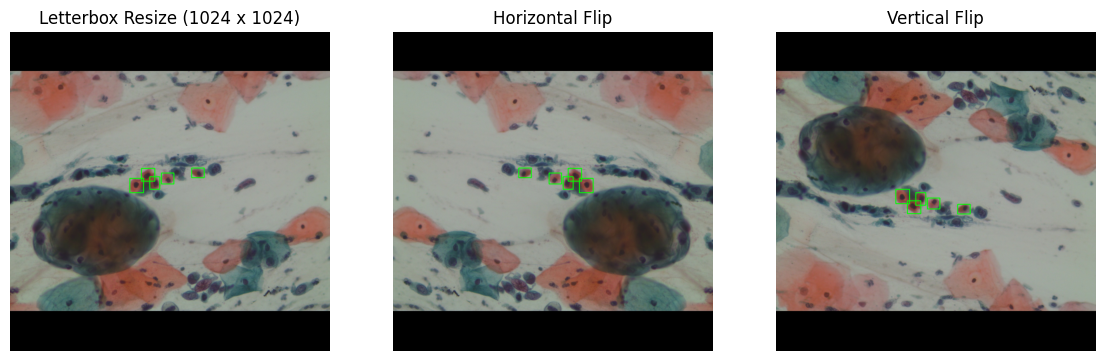


Example Label File:

0 0.49281005859375 0.460693359375 0.03908691406249998 0.034423828125
0 0.4312744140625 0.44921875 0.0419921875 0.039306640625
0 0.3961181640625 0.48291015625 0.04296875 0.044189453125
0 0.4527587890625 0.47509765625 0.03173828125 0.039306640625
0 0.5870361328125 0.44330078125 0.03891601562499991 0.030029296875


In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = 1024

# -----------------------------
# Example input paths
# -----------------------------

image_path = "detector_dataset/train/images/001.jpg"
label_path = "detector_dataset/train/labels/001.txt"


# -----------------------------
# Letterbox resize
# -----------------------------

def letterbox(image):

    h, w = image.shape[:2]

    scale = min(IMG_SIZE/w, IMG_SIZE/h)

    new_w = int(w * scale)
    new_h = int(h * scale)

    resized = cv2.resize(image, (new_w, new_h))

    canvas = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)

    pad_x = (IMG_SIZE - new_w) // 2
    pad_y = (IMG_SIZE - new_h) // 2

    canvas[pad_y:pad_y+new_h, pad_x:pad_x+new_w] = resized

    return canvas


# -----------------------------
# Read YOLO label
# -----------------------------

def read_label(path):

    boxes = []

    with open(path) as f:
        for line in f:
            c, x, y, w, h = map(float, line.split())
            boxes.append((c, x, y, w, h))

    return boxes


# -----------------------------
# Draw bounding boxes
# -----------------------------

def draw_boxes(image, boxes):

    h, w = image.shape[:2]

    img = image.copy()

    for c, x, y, bw, bh in boxes:

        xmin = int((x - bw/2) * w)
        ymin = int((y - bh/2) * h)

        xmax = int((x + bw/2) * w)
        ymax = int((y + bh/2) * h)

        cv2.rectangle(img, (xmin,ymin), (xmax,ymax), (0,255,0), 2)

    return img


# -----------------------------
# Load original image
# -----------------------------

orig = cv2.imread(image_path)
orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)

oh, ow = orig.shape[:2]

boxes = read_label(label_path)

orig_box = draw_boxes(orig, boxes)

print("Original Image Size:")
print(f"Width = {ow}")
print(f"Height = {oh}")


# -----------------------------
# Letterbox resize
# -----------------------------

letter = letterbox(orig)

lh, lw = letter.shape[:2]

letter_box = draw_boxes(letter, boxes)

print("\nAfter Letterbox Resize:")
print(f"Width = {lw}")
print(f"Height = {lh}")


# -----------------------------
# Augmentation
# -----------------------------

hflip = cv2.flip(letter_box, 1)
vflip = cv2.flip(letter_box, 0)


# -----------------------------
# Plot results
# -----------------------------

plt.figure(figsize=(14,8))

plt.subplot(1,3,1)
plt.title(f"Letterbox Resize ({lw} x {lh})")
plt.imshow(letter_box)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Horizontal Flip")
plt.imshow(hflip)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Vertical Flip")
plt.imshow(vflip)
plt.axis("off")

plt.show()


# -----------------------------
# Show label explanation
# -----------------------------

print("\nExample Label File:\n")

with open(label_path) as f:
    for line in f:
        print(line.strip())



### **Train Detector**

In [7]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 15.8 MB/s eta 0:00:00


In [10]:
from ultralytics import YOLO

# load pretrained model
model = YOLO("yolov8n.pt")

# train model
results = model.train(
    data="data.yaml",
    epochs=50,
    imgsz=1024,
    batch=8,
    device=0,
    workers=4,
    project="pap_smear_detector",
    name="yolov8n_detector",
    save=True
)

print("Training finished")

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_detector3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots

In [15]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/pap_smear_detector/yolov8n_detector3/weights/best.pt")

metrics = model.val(
    data="data.yaml",
    split="test",
    imgsz=1024
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1612.1±1610.1 MB/s, size: 221.1 KB)
val: Scanning /content/detector_dataset/test/labels... 300 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 300/300 699.4it/s 0.4s
val: New cache created: /content/detector_dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 2.2it/s 8.6s
                   all        300       1233      0.539      0.629      0.603      0.463
Speed: 7.3ms preprocess, 9.4ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /content/runs/detect/val


In [16]:
print("\nEvaluation Results")

print("mAP@0.5 :", metrics.box.map50)
print("mAP@0.5:0.95 :", metrics.box.map)

print("Precision :", metrics.box.mp)
print("Recall :", metrics.box.mr)


Evaluation Results
mAP@0.5 : 0.6026244559443167
mAP@0.5:0.95 : 0.46294130132366157
Precision : 0.5386059802846529
Recall : 0.6285482562854826
